# Ljungqvist & Sargent (2018), Chapter 5 --- Linear Quadratic Dynamic Programming

Companion notebook to `ls_solutions_ch05.pdf`. Chapter 5 has **14 end-of-chapter exercises**
(printed pp. 145--155). One section per exercise. Every analytical claim in the PDF is checked
here by an independent route with an `assert`: Riccati iteration vs `scipy.linalg.solve_discrete_are`
vs Howard policy iteration, closed forms vs the LQ machinery, Lyapunov solutions vs Monte Carlo,
the Kalman log-likelihood vs the direct Gaussian density.

Notation is the book's: maximise $-\sum_t\beta^t\{x_t'Rx_t+u_t'Qu_t+2u_t'Hx_t\}$ s.t.
$x_{t+1}=Ax_t+Bu_t+C\epsilon_{t+1}$; value $-x'Px-d$; policy $u=-Fx$.
The book's "Matlab program" requests are answered with Python functions (numpy/scipy only).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are, solve_discrete_lyapunov

plt.rcParams.update({"pdf.fonttype": 42, "font.size": 10})  # TrueType, never Type 3
FIG = "fig/"
np.set_printoptions(precision=5, suppress=True, linewidth=110)


def olrp(beta, A, B, R, Q, H=None, tol=1e-12, maxit=200_000, P0=None):
    """Exercise 5.1(b): solve the discounted regulator with cross term by iterating on the Riccati map.

    beta: discount factor; A (n,n), B (n,k): law of motion x' = Ax + Bu (+ C eps);
    R (n,n), Q (k,k), H (k,n): return -(x'Rx + u'Qu + 2u'Hx); H=None means no cross term.
    Starts from P0 (default zeros). Returns (P, F, iterations); u = -F x.
    Raises RuntimeError if the iteration has not converged after maxit steps.
    """
    n, k = B.shape
    H = np.zeros((k, n)) if H is None else H
    P = np.zeros((n, n)) if P0 is None else P0
    for it in range(1, maxit + 1):
        G = beta * B.T @ P @ A + H
        Pn = R + beta * A.T @ P @ A - G.T @ np.linalg.solve(Q + beta * B.T @ P @ B, G)
        Pn = (Pn + Pn.T) / 2
        if np.max(np.abs(Pn - P)) < tol * max(1.0, np.max(np.abs(Pn))):
            P = Pn
            break
        P = Pn
    else:
        raise RuntimeError("Riccati iteration did not converge")
    F = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
    return P, F, it


def dare(beta, A, B, R, Q, H=None):
    """Independent route: scipy's stabilising DARE solution, discounting absorbed as sqrt(beta)*A, sqrt(beta)*B.

    scipy solves A'XA - X - (A'XB+S)(R+B'XB)^{-1}(B'XA+S') + Q = 0; with S = H' this is equation (1) of 5.1.
    """
    n, k = B.shape
    H = np.zeros((k, n)) if H is None else H
    sb = np.sqrt(beta)
    P = solve_discrete_are(sb * A, sb * B, R, Q, s=H.T)
    F = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
    return P, F


def evaluate(beta, A, B, R, Q, H, F):
    """Value matrix P_F of following u=-Fx forever (policy evaluation, eq. (5.2.10) with cross term)."""
    Rf = R + F.T @ Q @ F - H.T @ F - F.T @ H
    Af = A - B @ F
    return solve_discrete_lyapunov(np.sqrt(beta) * Af.T, Rf)   # P = Rf + beta Af' P Af


def howard(beta, A, B, R, Q, H, F0, tol=1e-12, maxit=100):
    """Howard policy iteration (5.2.10)-(5.2.11), cross term allowed. Returns (P, F, iterations, history of F)."""
    F, hist = F0, [F0]
    for it in range(1, maxit + 1):
        P = evaluate(beta, A, B, R, Q, H, F)
        Fn = np.linalg.solve(Q + beta * B.T @ P @ B, beta * B.T @ P @ A + H)
        hist.append(Fn)
        if np.max(np.abs(Fn - F)) < tol:
            return evaluate(beta, A, B, R, Q, H, Fn), Fn, it, hist
        F = Fn
    raise RuntimeError("policy iteration did not converge")


def d_const(beta, P, C):
    """Constant in v(x) = -x'Px - d for shocks C eps, eq. (5.3.5)."""
    return beta / (1 - beta) * np.trace(P @ C @ C.T)

## Exercise 5.1 --- Riccati equation with a cross term

Claim (PDF): $P=R+\beta A'PA-(\beta A'PB+H')(Q+\beta B'PB)^{-1}(\beta B'PA+H)$,
$F=(Q+\beta B'PB)^{-1}(\beta B'PA+H)$. `olrp` above is the program of part (b).
Independent routes on random problems: (i) scipy DARE with `s=H'`;
(ii) the change of control $\tilde u=u+Q^{-1}Hx$, which removes the cross term;
(iii) the Bellman equation holds: brute-force maximisation over $u$ gives $u=-Fx$.

In [2]:
rng = np.random.default_rng(5)
for trial in range(5):
    n, k, beta = 4, 2, 0.9
    A = rng.normal(size=(n, n)) * 0.5
    B = rng.normal(size=(n, k))
    L = rng.normal(size=(n + k, n + k)); J = L @ L.T + 0.5 * np.eye(n + k)   # joint [[R,H'],[H,Q]] > 0
    R, Hm, Q = J[:n, :n], J[n:, :n], J[n:, n:]
    P1, F1, it = olrp(beta, A, B, R, Q, Hm)
    P2, F2 = dare(beta, A, B, R, Q, Hm)
    # (ii) no-cross-term transform: u = ut - Q^{-1}H x  =>  R* = R - H'Q^{-1}H, A* = A - B Q^{-1} H
    Qi = np.linalg.inv(Q)
    P3, F3, _ = olrp(beta, A - B @ Qi @ Hm, B, R - Hm.T @ Qi @ Hm, Q)
    F3 = F3 + Qi @ Hm
    assert np.allclose(P1, P2, atol=1e-8) and np.allclose(F1, F2, atol=1e-8)
    assert np.allclose(P1, P3, atol=1e-8) and np.allclose(F1, F3, atol=1e-8)
    # (iii) Bellman: RHS as a quadratic in u, maximised by solving its FOC numerically on a random x
    x = rng.normal(size=n)
    rhs = lambda u: -(x @ R @ x + u @ Q @ u + 2 * u @ Hm @ x + beta * (A @ x + B @ u) @ P1 @ (A @ x + B @ u))
    from scipy.optimize import minimize
    ustar = minimize(lambda u: -rhs(u), np.zeros(k), tol=1e-14).x
    assert np.allclose(ustar, -F1 @ x, atol=1e-5) and abs(rhs(-F1 @ x) + x @ P1 @ x) < 1e-8
    print(f"trial {trial}: Riccati iterations = {it}, max|P_iter - P_scipy| = {np.max(abs(P1-P2)):.1e}")

trial 0: Riccati iterations = 24, max|P_iter - P_scipy| = 3.9e-12
trial 1: Riccati iterations = 17, max|P_iter - P_scipy| = 1.5e-12
trial 2: Riccati iterations = 74, max|P_iter - P_scipy| = 5.0e-11
trial 3: Riccati iterations = 21, max|P_iter - P_scipy| = 2.6e-12
trial 4: Riccati iterations = 19, max|P_iter - P_scipy| = 2.3e-12


## Exercise 5.2 --- (5.2.10)--(5.2.11) are Howard's policy improvement algorithm

Checks: (i) `evaluate` (the Lyapunov equation (5.2.10)) equals the discounted sum of returns of
the fixed rule, by direct summation of the series $\sum_k\beta^k(A-BF)'^k(R+F'QF)(A-BF)^k$ and by simulation;
(ii) values improve monotonically, $P_{j+1}\le P_j$; (iii) the limit solves the Riccati equation
and equals the Riccati-iteration limit. Test problem: exercise 5.3 (built below, reused).

Howard: 2 improvements;  Riccati iteration: 496 steps

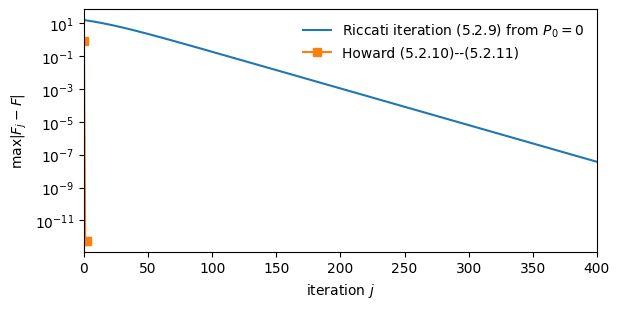

Howard errors: [0.81671 0.      0.     ]


In [3]:
def ex53_matrices(beta=0.95, r=1 / 0.95 - 1, b=30.0, gam=1.0, rho1=1.2, rho2=-0.3):
    """Exercise 5.3 mapped into the regulator: x=[a, y, y_{-1}, 1], u=i."""
    A = np.array([[1, 0, 0, 0], [0, rho1, rho2, 0], [0, 1, 0, 0], [0, 0, 0, 1.0]])
    B = np.array([[1.0], [0], [0], [0]])
    S = np.array([[r, 1, 0, -b]])                     # c - b = S x - i
    R = S.T @ S; Q = np.array([[1 + gam]]); H = -S
    return A, B, R, Q, H, S

beta = 0.95
A, B, R, Q, H, S = ex53_matrices()
F0 = np.array([[0.0, 0.5, 0.0, 0.0]])               # an arbitrary stable initial rule: invest half of income
assert np.max(abs(np.linalg.eigvals(A - B @ F0))) < 1 / np.sqrt(beta)

# (i) evaluation: Lyapunov vs truncated series vs Monte-Carlo-free deterministic simulation of returns
P0 = evaluate(beta, A, B, R, Q, H, F0)
Af, Rf = A - B @ F0, R + F0.T @ Q @ F0 - H.T @ F0 - F0.T @ H
Pser, M = np.zeros_like(P0), np.eye(4)
for kk in range(3000):
    Pser += beta**kk * M.T @ Rf @ M; M = Af @ M
assert np.allclose(P0, Pser, rtol=1e-9)
x0 = np.array([1.0, 2.0, 1.5, 1.0]); x, tot = x0.copy(), 0.0
for t in range(3000):
    u = -F0 @ x
    tot += beta**t * (x @ R @ x + u @ Q @ u + 2 * u @ H @ x); x = A @ x + B @ u
assert np.isclose(tot, x0 @ P0 @ x0, rtol=1e-9)

# (ii)-(iii) Howard iterations; monotone improvement in the psd order
Ph, Fh, it_h, hist = howard(beta, A, B, R, Q, H, F0)
Ps = [evaluate(beta, A, B, R, Q, H, F) for F in hist]
for Pa, Pb in zip(Ps[:-1], Ps[1:]):
    assert np.min(np.linalg.eigvalsh(Pa - Pb)) > -1e-7 * np.max(abs(Pa))   # P_j - P_{j+1} psd
Pr, Fr, it_r = olrp(beta, A, B, R, Q, H)
Pd, Fd = dare(beta, A, B, R, Q, H)
assert np.allclose(Fh, Fr, atol=1e-8) and np.allclose(Fh, Fd, atol=1e-8)
assert np.allclose(Ph, Pd, rtol=1e-8, atol=1e-6)
print(f"Howard: {it_h} improvements;  Riccati iteration: {it_r} steps")

# convergence plot (log distance of F_j to F*)
errH = [np.max(abs(F - Fd)) for F in hist]
P, errR = np.zeros((4, 4)), []
for j in range(it_r):
    G = beta * B.T @ P @ A + H
    Fj = np.linalg.solve(Q + beta * B.T @ P @ B, G); errR.append(np.max(abs(Fj - Fd)))
    P = R + beta * A.T @ P @ A - G.T @ np.linalg.solve(Q + beta * B.T @ P @ B, G)
fig, ax = plt.subplots(figsize=(6.3, 3.2))
ax.semilogy(np.arange(len(errR)), np.maximum(errR, 1e-16), label="Riccati iteration (5.2.9) from $P_0=0$")
ax.semilogy(np.arange(len(errH)), np.maximum(errH, 1e-16), "s-", label="Howard (5.2.10)--(5.2.11)")
ax.set_xlabel("iteration $j$"); ax.set_ylabel(r"$\max|F_j-F|$"); ax.set_xlim(0, 400)
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(FIG + "ls05_riccati_vs_howard.pdf"); plt.show()
print("Howard errors:", np.array(errH))

## Exercise 5.3 --- household with adjustment cost on investment

$x_t=[a_t,y_t,y_{t-1},1]'$, $u_t=i_t$; $c_t-b=Sx_t-i_t$ with $S=[r,1,0,-b]$; so
$R=S'S$, $Q=1+\gamma$, $H=-S$. Parameters from the book: $\beta=.95$, $1+r=.95^{-1}$, $b=30$,
$\gamma=1$, $\rho_1=1.2$, $\rho_2=-.3$.

In [4]:
A, B, R, Q, H, S = ex53_matrices()
P53, F53, it53 = olrp(beta, A, B, R, Q, H)
assert np.allclose(F53, dare(beta, A, B, R, Q, H)[1], atol=1e-8)
Fc53 = S[0] + F53[0]                                      # c = Sx - i + b = (S + F)x + b  -> report c rule too
print("investment rule  i = -F x,  F =", F53)
print("consumption rule c = b + (S+F) x:", Fc53 + np.array([0, 0, 0, 30.0]))
print("eigenvalues of A-BF:", np.linalg.eigvals(A - B @ F53))
# economic check: Euler equation. FOC in i: (c_t-b)+gamma i_t... verified by simulation of the stochastic-free path
# (1+r)beta=1 => E[(c_{t+1}-b) - gamma i_{t+1}] relation; check the Euler eq. -(c_t-b)+... directly:
# d/di_t: (c_t-b) - gamma i_t + beta*[ (1+r)... ] -- we check it numerically along a path:
x = np.array([5.0, 2.0, 1.0, 1.0]); path = []
for t in range(200):
    i_t = -(F53 @ x)[0]; c_t = S[0] @ x - i_t + 30.0; path.append((c_t, i_t)); x = A @ x + B[:, 0] * i_t
path = np.array(path)
# FOC w.r.t. a_{t+1} (= choice of i_t): (c_t-b) - gamma i_t = beta[(1+r)(c_{t+1}-b) - gamma i_{t+1}]
lhs = (path[:-1, 0] - 30) - 1.0 * path[:-1, 1]
rhs = beta * ((1 / 0.95) * (path[1:, 0] - 30) - 1.0 * path[1:, 1])
assert np.allclose(lhs, rhs, atol=1e-8)
print("Euler equation residual along a path:", np.max(abs(lhs - rhs)))

investment rule  i = -F x,  F = [[-0.      -0.31671 -0.05589  0.     ]]
consumption rule c = b + (S+F) x: [ 0.05263  0.68329 -0.05589  0.     ]
eigenvalues of A-BF: [1.      0.84495 0.35505 1.     ]
Euler equation residual along a path: 2.69579913947382e-11


## Exercise 5.4 --- durables and habits

$x_t=[a_t,y_t,y_{t-1},h_t,1]'$, $u_t=i_t$. $s_t-b=S x_t-\pi i_t$ with $S=[\pi r,\pi,0,\lambda,-b]$,
$h_{t+1}=\theta r a_t+\theta y_t+\delta h_t-\theta i_t$. So $R=S'S$, $Q=\pi^2+\gamma$, $H=-\pi S$.

b: durables (1,.05,.95,1) 
  i = -F x, F = [ 0.29911  1.5205  -0.61213 -0.28416  0.     ] 
  c = coeffs @ x: [ 0.35174  2.5205  -0.61213 -0.28416  0.     ] 
  eig(A-BF): [1.     0.3667 0.3551 0.8449 1.    ]
c: habits (-1,1,.95,1) 
  i = -F x, F = [ 0.17917  0.68809 -0.42542 -0.17021 -0.     ] 
  c = coeffs @ x: [ 0.2318   1.68809 -0.42542 -0.17021 -0.     ] 
  eig(A-BF): [1.     0.6006 0.3551 0.8449 1.    ]


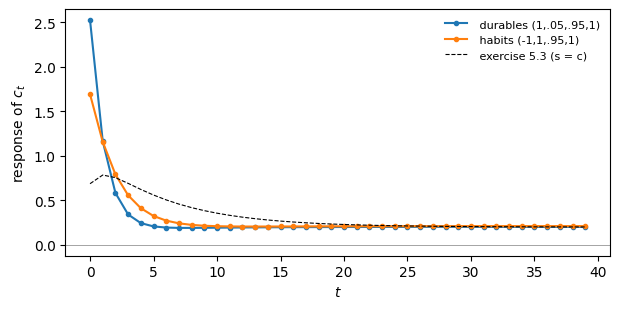

In [5]:
def ex54(lam, pi, dlt, th, beta=0.95, r=1 / 0.95 - 1, b=30.0, gam=1.0, rho1=1.2, rho2=-0.3):
    A = np.array([[1, 0, 0, 0, 0], [0, rho1, rho2, 0, 0], [0, 1, 0, 0, 0],
                  [th * r, th, 0, dlt, 0], [0, 0, 0, 0, 1.0]])
    B = np.array([[1.0], [0], [0], [-th], [0]])
    S = np.array([[pi * r, pi, 0, lam, -b]])
    R = S.T @ S; Q = np.array([[pi**2 + gam]]); H = -pi * S
    P, F, it = olrp(beta, A, B, R, Q, H)
    assert np.allclose(F, dare(beta, A, B, R, Q, H)[1], atol=1e-7)
    Fh = howard(beta, A, B, R, Q, H, F * 0.5 if np.max(abs(np.linalg.eigvals(A - 0.5 * B @ F))) < 1 / np.sqrt(beta) else F)[1]
    assert np.allclose(F, Fh, atol=1e-7)
    return A, B, F

cases = {"b: durables (1,.05,.95,1)": (1, .05, .95, 1), "c: habits (-1,1,.95,1)": (-1, 1, .95, 1)}
fig, ax = plt.subplots(figsize=(6.3, 3.2))
res54 = {}
for lab, p in cases.items():
    A4, B4, F4 = ex54(*p)
    cvec = np.array([1 / 0.95 - 1, 1, 0, 0, 0]) + F4[0]          # c = r a + y - i = (e_c + F) x
    res54[lab] = (F4[0], cvec)
    print(lab, "\n  i = -F x, F =", F4[0], "\n  c = coeffs @ x:", cvec,
          "\n  eig(A-BF):", np.round(np.linalg.eigvals(A4 - B4 @ F4), 4))
    # impulse response of consumption to a unit income shock at t=0 (deviation from zero-shock path)
    dx = np.array([0, 1.0, 0, 0, 0]); irf = []
    for t in range(40):
        irf.append(cvec @ dx); dx = (A4 - B4 @ F4) @ dx
    ax.plot(irf, marker=".", label=lab.split(":")[1])
# benchmark: exercise 5.3 (no durables/habits): s=c
A3, B3, R3, Q3, H3, S3 = ex53_matrices(); dx = np.array([0, 1.0, 0, 0]); irf = []
for t in range(40):
    irf.append((S3[0] + F53[0]) @ dx + 0); dx = (A3 - B3 @ F53) @ dx
ax.plot(irf, "k--", lw=0.8, label=" exercise 5.3 (s = c)")
ax.axhline(0, color="gray", lw=0.5); ax.set_xlabel("$t$"); ax.set_ylabel("response of $c_t$")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); fig.savefig(FIG + "ls05_durables_habits.pdf"); plt.show()

## Exercise 5.5 --- expected discounted sum of an ARMA(2,1)

$x_t=[y_t,y_{t-1},w_t]'$, $x_{t+1}=A x_t+Cw_{t+1}$, $y_t=Gx_t$; answer $G(I-\beta A)^{-1}x_t$, whose closed form is
$g_1=1/(1-\beta\rho_1-\beta^2\rho_2)$, $g_2=\beta\rho_2 g_1$, $g_3=\beta\gamma g_1$.

In [6]:
def discounted_sum_coeffs(beta, rho1, rho2, gam):
    """Exercise 5.5(a): row vector g with E[sum_j beta^j y_{t+j} | y^t, w^t] = g @ [y_t, y_{t-1}, w_t]."""
    A = np.array([[rho1, rho2, gam], [1, 0, 0], [0, 0, 0.0]])
    G = np.array([1.0, 0, 0])
    assert np.max(abs(np.linalg.eigvals(A))) < 1 / beta
    return G @ np.linalg.inv(np.eye(3) - beta * A), A

b5, r1, r2, g5 = 0.95, 1.2, -0.4, 0.5
g, A5 = discounted_sum_coeffs(b5, r1, r2, g5)
g1 = 1 / (1 - b5 * r1 - b5**2 * r2)
assert np.allclose(g, [g1, b5 * r2 * g1, b5 * g5 * g1])
# independent route: Monte Carlo of the realised discounted sum from a fixed state
rng = np.random.default_rng(55); N, T = 40_000, 400
x0 = np.array([1.0, 0.5, 0.3]); X = np.tile(x0, (N, 1)); tot = np.zeros(N)
for t in range(T):
    tot += b5**t * X[:, 0]
    w = rng.standard_normal(N)
    X = X @ A5.T + np.outer(w, [1, 0, 1])
se = tot.std() / np.sqrt(N)
assert abs(tot.mean() - g @ x0) < 5 * se
print("g =", g, " g @ x0 =", g @ x0, " MC =", tot.mean(), "+/-", se)
print("|eig(A)| =", np.abs(np.linalg.eigvals(A5)))

g = [ 4.52489 -1.71946  2.14932]  g @ x0 = 4.30995475113122  MC = 4.389778642122487 +/- 0.10232929024385892
|eig(A)| = [0.63246 0.63246 0.     ]


## Exercise 5.6 --- value of an endowment with a stochastic discount factor

State $x_t=[1,d_t,d_{t-1}]'$; $s_td_t=\beta^t x_t'Mx_t$ with $M_{12}=M_{21}=b_0/2$, $M_{22}=-b_1$.
$v_0=x_0'Px_0+\beta(1-\beta)^{-1}\mathrm{tr}(PCC')$ with $P=M+\beta A'PA$.
Parameters (not in the book): $\beta=.95$, $\rho_0=1$, $\rho_1=1.2$, $\rho_2=-.3$, $\sigma_d=.5$, $b_0=1$, $b_1=.02$.

In [7]:
def endowment_value(beta, rho0, rho1, rho2, sig, b0, b1, x0, tol=1e-13, maxit=100_000):
    """Exercise 5.6(a): recursive algorithm. Iterate P_{j+1} = M + beta A'P_j A from P_0 = 0.

    Returns (v0, P, iterations); raises RuntimeError if the iteration diverges (v0 infinite).
    """
    A = np.array([[1, 0, 0], [rho0, rho1, rho2], [0, 1, 0.0]])
    C = np.array([[0], [sig], [0.0]])
    M = np.array([[0, b0 / 2, 0], [b0 / 2, -b1, 0], [0, 0, 0.0]])
    P = np.zeros((3, 3))
    for it in range(maxit):
        Pn = M + beta * A.T @ P @ A
        if not np.all(np.isfinite(Pn)) or np.max(abs(Pn)) > 1e14:
            raise RuntimeError("diverges")
        if np.max(abs(Pn - P)) < tol * max(1, np.max(abs(Pn))):
            break
        P = Pn
    else:
        raise RuntimeError("no convergence")
    return x0 @ Pn @ x0 + beta / (1 - beta) * np.trace(Pn @ C @ C.T), Pn, it

pars6 = dict(beta=0.95, rho0=1.0, rho1=1.2, rho2=-0.3, sig=0.5, b0=1.0, b1=0.02)
x06 = np.array([1.0, 9.0, 8.5])
v0, P6, it6 = endowment_value(**pars6, x0=x06)
# route 2: scipy Lyapunov  P = beta A'PA + M
A6 = np.array([[1, 0, 0], [1.0, 1.2, -0.3], [0, 1, 0.0]])
M6 = np.array([[0, .5, 0], [.5, -.02, 0], [0, 0, 0.0]])
assert np.allclose(P6, solve_discrete_lyapunov(np.sqrt(0.95) * A6.T, M6), rtol=1e-8)
# route 3: Monte Carlo
rng = np.random.default_rng(6); N, T = 40_000, 700
d, dl, tot = np.full(N, x06[1]), np.full(N, x06[2]), np.zeros(N)
for t in range(T):
    tot += 0.95**t * (1.0 - 0.02 * d) * d
    d, dl = 1.0 + 1.2 * d - 0.3 * dl + 0.5 * rng.standard_normal(N), d
se = tot.std() / np.sqrt(N)
assert abs(tot.mean() - v0) < 5 * se
print(f"v0 = {v0:.4f} (iterations {it6});  Monte Carlo {tot.mean():.4f} +/- {se:.4f}")

# part (b): finiteness <=> max |root| < beta^{-1/2}. Unit root still finite; root 1.05 diverges.
for r1_, r2_ in ((1.9, -0.9), (1.55, -0.525)):
    lam = np.roots([1, -r1_, -r2_]); ok = np.max(abs(lam)) < 1 / np.sqrt(0.95)
    try:
        endowment_value(0.95, 1.0, r1_, r2_, 0.5, 1.0, 0.02, x06); finite = True
    except RuntimeError:
        finite = False
    assert finite == ok
    print(f"rho=({r1_},{r2_}) roots {np.round(lam, 4)}: beta*max|root|^2 = {0.95*np.max(abs(lam))**2:.4f} -> finite: {finite}")

v0 = 156.7200 (iterations 531);  Monte Carlo 156.7365 +/- 0.0350
rho=(1.9,-0.9) roots [1.  0.9]: beta*max|root|^2 = 0.9500 -> finite: True
rho=(1.55,-0.525) roots [1.05 0.5 ]: beta*max|root|^2 = 1.0474 -> finite: False


## Exercise 5.7 --- dynamic Laffer curves

Program: given $p_0$, iterate $M_t=M_{t-1}+gp_t$, $p_{t+1}=(\gamma_1p_t-M_t)/\gamma_2$.
Closed form: $p_t=c_1\lambda_1^t+c_2\lambda_2^t$, roots of $\gamma_2\lambda^2-(\gamma_1+\gamma_2-g)\lambda+\gamma_1=0$;
minimal $p_0=M_{-1}/[\gamma_2(\lambda_2-1)]$.

g=0.05: lambda1=1.001002, lambda2=1.997998, p0_min=2.004012, real balances 49.9499 / 0.1001
g=0.075: lambda1=1.001505, lambda2=1.996995, p0_min=2.006027, real balances 49.9248 / 0.1502
c2 at p0_min: 8.908545575205313e-16
revenue-maximising pi* = sqrt(g1/g2) = 1.4142135623730951  max revenue = 8.578643762690497


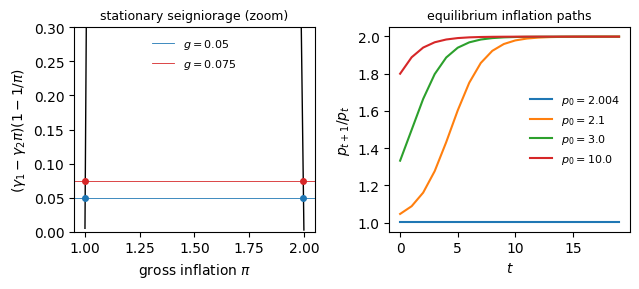

In [8]:
def laffer_roots(g1, g2, g):
    lo, hi = np.sort(np.roots([g2, -(g1 + g2 - g), g1]).real)
    return lo, hi

def equilibrium_path(p0, T, g1=100.0, g2=50.0, g=0.05, Mm1=100.0):
    """Exercise 5.7(a): forward recursion of (1)-(2) from p0. Returns arrays p[0..T], M[0..T-1]."""
    p, M = [p0], []
    Mprev = Mm1
    for t in range(T):
        Mt = Mprev + g * p[-1]; M.append(Mt)
        p.append((g1 * p[-1] - Mt) / g2); Mprev = Mt
    return np.array(p), np.array(M)

def closed_form(p0, T, g1=100.0, g2=50.0, g=0.05, Mm1=100.0):
    l1, l2 = laffer_roots(g1, g2, g)
    p1 = ((g1 - g) * p0 - Mm1) / g2
    c2 = (p1 - l1 * p0) / (l2 - l1); c1 = p0 - c2
    t = np.arange(T + 1)
    return c1 * l1**t + c2 * l2**t, c1, c2

for g in (0.05, 0.075):
    l1, l2 = laffer_roots(100, 50, g)
    p0min = 100 / (50 * (l2 - 1))
    print(f"g={g}: lambda1={l1:.6f}, lambda2={l2:.6f}, p0_min={p0min:.6f}, "
          f"real balances {100-50*l1:.4f} / {100-50*l2:.4f}")
    # seigniorage identity at both stationary inflation rates
    for lam in (l1, l2):
        assert np.isclose((100 - 50 * lam) * (1 - 1 / lam), g)

l1, l2 = laffer_roots(100, 50, 0.05); p0min = 100 / (50 * (l2 - 1))
# forward program vs closed form, for several p0 >= p0_min
for p0 in (p0min, 3.0, 10.0, 1000.0, 5000.0):
    pf, Mf = equilibrium_path(p0, 25); pc, c1, c2 = closed_form(p0, 25)
    assert np.allclose(pf, pc, rtol=1e-6)   # forward recursion amplifies rounding at rate lambda2 ~ 2
    assert np.all(pf > 0) and np.all(Mf > 0)
    if p0 > p0min * 1.01:
        pl, Ml = equilibrium_path(p0, 200)
        assert abs(pl[-1] / pl[-2] - l2) < 1e-6 and abs(Ml[-1] / Ml[-2] - l2) < 1e-6
# at p0_min the closed form is exactly geometric at lambda1; slightly below, prices turn negative
pc, c1, c2 = closed_form(p0min, 5); print("c2 at p0_min:", c2)
assert abs(c2) < 1e-10 and np.allclose(pc[1:] / pc[:-1], l1)
pl, _ = equilibrium_path(p0min * 0.999, 60); assert pl.min() < 0
# eigen-decomposition route (section 5.5): p0_min kills the unstable eigen-direction of the companion matrix
Mc = np.array([[(100 + 50 - 0.05) / 50, -100 / 50], [1, 0]])
lam, V = np.linalg.eig(Mc); Vi = np.linalg.inv(V); j2 = np.argmax(lam.real)
# y_1 = [p1, p0] with p1 = ((g1-g)p0 - 100)/g2 : require (V^{-1} y_1)_{j2} = 0 -> linear in p0
f = lambda p0: (Vi @ np.array([((100 - 0.05) * p0 - 100) / 50, p0]))[j2]
p0_eig = -f(0.0) / (f(1.0) - f(0.0))
assert np.isclose(p0_eig, p0min, rtol=1e-10)

# Laffer curve and paths
pis = np.linspace(1.0001, 1.9999, 2000); rev = (100 - 50 * pis) * (1 - 1 / pis)
pistar = np.sqrt(2); assert np.isclose(pis[rev.argmax()], pistar, atol=1e-3)
print("revenue-maximising pi* = sqrt(g1/g2) =", pistar, " max revenue =", (100 - 50 * pistar) * (1 - 1 / pistar))
fig, axs = plt.subplots(1, 2, figsize=(6.5, 3.0))
axs[0].plot(pis, rev, "k", lw=1)
for g, col in ((0.05, "C0"), (0.075, "C3")):
    for lam in laffer_roots(100, 50, g):
        axs[0].plot(lam, g, "o", color=col, ms=4)
    axs[0].axhline(g, color=col, lw=0.6, label=f"$g={g}$")
axs[0].set_ylim(0, 0.3); axs[0].set_xlabel(r"gross inflation $\pi$"); axs[0].set_ylabel(r"$(\gamma_1-\gamma_2\pi)(1-1/\pi)$")
axs[0].set_title("stationary seigniorage (zoom)", fontsize=9); axs[0].legend(frameon=False, fontsize=8)
for p0 in (p0min, 2.1, 3.0, 10.0):
    pp, _ = equilibrium_path(p0, 20)
    axs[1].plot(pp[1:] / pp[:-1], label=f"$p_0={p0:.3f}$" if p0 == p0min else f"$p_0={p0}$")
axs[1].set_xlabel("$t$"); axs[1].set_ylabel(r"$p_{t+1}/p_t$"); axs[1].legend(frameon=False, fontsize=8)
axs[1].set_title("equilibrium inflation paths", fontsize=9)
fig.tight_layout(); fig.savefig(FIG + "ls05_laffer.pdf"); plt.show()

## Exercise 5.8 --- tax smoothing, and what a VAR on $[g_t,T_t]$ can recover

$x_t=[b_t,g_{Pt},g_{Tt},1]'$, $u_t=b_{t+1}$, $T_t=Sx_t+qu_t$ with $S=[-1,1,1,0]$.
$W(T)=w_1T+\tfrac12w_2T^2 = x'Rx+u'Qu+2u'Hx$ with $R=\tfrac12w_2S'S+\tfrac12w_1(e_4S+S'e_4')$,
$Q=\tfrac12w_2q^2$, $H=q(\tfrac12w_2S+\tfrac12w_1e_4')$. Closed form at $q=\beta$:
$T_t=g_{Pt}+\mu_T+\kappa(g_{Tt}-\mu_T)-(1-q)b_t$, $\kappa=(1-q)/(1-q\rho)$.
Parameters (not in the book): $\beta=q=.95$, $\rho=.8$, $\mu_T=.1$, $c_1=.01$, $c_2=.03$, $w_1=1$, $w_2=2$.

In [9]:
def ex58(beta=0.95, q=0.95, rho=0.8, muT=0.1, c1=0.01, c2=0.03, w1=1.0, w2=2.0):
    A = np.array([[0, 0, 0, 0], [0, 1, 0, 0], [0, 0, rho, (1 - rho) * muT], [0, 0, 0, 1.0]])
    B = np.array([[1.0], [0], [0], [0]])
    C = np.array([[0, 0], [c1, 0], [0, c2], [0, 0.0]])
    S = np.array([[-1.0, 1, 1, 0]]); e4 = np.array([[0, 0, 0, 1.0]])
    R = 0.5 * w2 * S.T @ S + 0.5 * w1 * (e4.T @ S + S.T @ e4)
    Q = np.array([[0.5 * w2 * q**2]]); H = q * (0.5 * w2 * S + 0.5 * w1 * e4)
    P, F = dare(beta, A, B, R, Q, H)             # stabilising solution = no-Ponzi (see PDF)
    F0 = np.array([[-1.0, 0, 0, 0]])             # a stable starting rule: b_{t+1} = b_t
    Ph, Fh, it, _ = howard(beta, A, B, R, Q, H, F0)
    assert np.allclose(F, Fh, atol=1e-7)
    Ao = A - B @ F                               # closed loop
    Tvec = S[0] - q * F[0]                       # T_t = Tvec @ x_t
    return dict(A=A, B=B, C=C, P=P, F=F, Ao=Ao, Tvec=Tvec, it=it, R=R, Q=Q, H=H)

m = ex58()
q, rho, muT = 0.95, 0.8, 0.1; kap = (1 - q) / (1 - q * rho)
T_closed = np.array([-(1 - q), 1, kap, muT * (1 - kap)])
assert np.allclose(m["Tvec"], T_closed, atol=1e-8)
print("T_t = Tvec @ [b, gP, gT, 1]:", m["Tvec"], " closed form:", T_closed, " (Howard improvements:", m["it"], ")")
# Riccati iteration from P0 = 0 instead finds the Ponzi scheme T_t = -w1/w2 (W' = 0), b exploding at rate 1/q
Pp, Fp, _ = olrp(0.95, m["A"], m["B"], m["R"], m["Q"], m["H"])
assert np.allclose(np.array([-1.0, 1, 1, 0]) - 0.95 * Fp[0], [0, 0, 0, -0.5], atol=1e-8)
assert np.isclose(np.max(abs(np.linalg.eigvals(m["A"] - m["B"] @ Fp))), 1 / 0.95)
print("eig of closed loop (stabilising):", np.round(np.linalg.eigvals(m["Ao"]), 6))
# w1, w2 drop out when q = beta
for w1, w2 in ((0.0, 1.0), (3.0, 0.5)):
    assert np.allclose(ex58(w1=w1, w2=w2)["F"], m["F"], atol=1e-8)
# taxes are a martingale: E_t T_{t+1} = T_t  <=>  Tvec @ Ao = Tvec
assert np.allclose(m["Tvec"] @ m["Ao"], m["Tvec"], atol=1e-8)
print("innovation loadings of T: Tvec @ C =", m["Tvec"] @ m["C"], " = [c1, kappa c2] =", [0.01, kap * 0.03])
# when q != beta the rule depends on w1/w2 (not on the scale of W)
mA, mB, mC = ex58(beta=0.94, w1=1, w2=2), ex58(beta=0.94, w1=2, w2=4), ex58(beta=0.94, w1=1, w2=4)
assert np.allclose(mA["F"], mB["F"], atol=1e-7) and not np.allclose(mA["F"], mC["F"], atol=1e-4)

# (c)-(d) VAR for z=[g,T] from the steady-state Kalman filter (5.6.3): z_{t+1} = sum_j G(A-KG)^j K z_{t-j} + a_{t+1}
def kalman_ss(A, C, G, Rm, tol=1e-15, maxit=100_000):
    """Steady-state Kalman gain and innovation covariance by iterating (5.6.3) from a diffuse Sigma_0.

    Sigma_0 = I on the stochastic states (0 on the known constant). Starting from Sigma_0 = CC' instead
    lands on a non-stabilising fixed point (A-KG has the root 1/q), see the PDF.
    """
    Sig = np.diag(np.r_[np.ones(A.shape[0] - 1), 0.0])
    for it in range(maxit):
        Om = G @ Sig @ G.T + Rm
        K = A @ Sig @ G.T @ np.linalg.inv(Om)
        Sn = A @ Sig @ A.T + C @ C.T - K @ Om @ K.T
        if np.max(abs(Sn - Sig)) < tol:
            break
        Sig = Sn
    return K, Sn, G @ Sn @ G.T + Rm

def var_coeffs(mod, nlags=6, extra_obs=None, Rm=None):
    G = np.vstack([np.array([0, 1, 1, 0.0]), mod["Tvec"]]) if extra_obs is None else extra_obs
    Rm = np.zeros((G.shape[0], G.shape[0])) if Rm is None else Rm
    K, Sig, Om = kalman_ss(mod["Ao"], mod["C"], G, Rm)
    AK = mod["Ao"] - K @ G
    return [G @ np.linalg.matrix_power(AK, j) @ K for j in range(nlags)], Om, Sig

Aj, Om, Sig = var_coeffs(m)
print("VAR lag-1 coefficient matrix (on [g,T]):\n", Aj[0], "\ninnovation covariance:\n", Om)
# the VAR is invariant to (w1, w2) when q = beta, and moves with rho
for w1, w2 in ((0.0, 1.0), (3.0, 0.5)):
    Aj2, Om2, _ = var_coeffs(ex58(w1=w1, w2=w2))
    assert all(np.allclose(X, Y, atol=1e-8) for X, Y in zip(Aj, Aj2)) and np.allclose(Om, Om2)
assert not np.allclose(var_coeffs(ex58(rho=0.5))[0][0], Aj[0], atol=1e-3)
Gz = np.vstack([np.array([0, 1, 1, 0.0]), m["Tvec"]])
Kz, Sz, Oz = kalman_ss(m["Ao"], m["C"], Gz, np.zeros((2, 2)))
eAKG = np.linalg.eigvals(m["Ao"] - Kz @ Gz)
print("eig(A-KG):", np.round(eAKG, 6), "  GCC'G' =", Gz @ m["C"] @ m["C"].T @ Gz.T)
assert np.isclose(np.sort(abs(eAKG))[-2], 0.95)            # root 1/q flipped to q (non-fundamental shocks)
assert Oz[0, 0] > (Gz @ m["C"] @ m["C"].T @ Gz.T)[0, 0] * 1.02
# independent route: OLS VAR (40 lags, constant) on a long simulation of the closed loop
rng = np.random.default_rng(58); Tn = 200_000
x = np.array([0.0, 0.2, 0.1, 1.0]); Z = np.empty((Tn, 2))
E = rng.standard_normal((Tn, 2))
for t in range(Tn):
    Z[t] = [x[1] + x[2], m["Tvec"] @ x]
    x = m["Ao"] @ x + m["C"] @ E[t]
p = 40; Y = Z[p:]; Xr = np.hstack([Z[p - j - 1:Tn - j - 1] for j in range(p)] + [np.ones((Tn - p, 1))])
coef = np.linalg.lstsq(Xr, Y, rcond=None)[0]
resid = Y - Xr @ coef; Om_ols = resid.T @ resid / len(Y)
A1_ols = coef[:2].T
print("OLS lag-1:", A1_ols, "OLS innovation covariance:", Om_ols)
assert np.allclose(A1_ols, Aj[0], atol=0.03)
assert np.allclose(Om_ols, Om, rtol=0.03, atol=2e-6)

# (e) adding a noisy debt series  b~_t = b_t + c3 w_{3,t+1}: three observables, R = diag(0,0,c3^2)
G3 = np.vstack([np.array([0, 1, 1, 0.0]), m["Tvec"], np.array([1.0, 0, 0, 0])])
for c3 in (0.1, 1.0):
    Aj3, Om3, Sig3 = var_coeffs(m, extra_obs=G3, Rm=np.diag([0, 0, c3**2]))
    print(f"c3={c3}: trace of state-estimation error Sigma = {np.trace(Sig3):.3e} (vs {np.trace(Sig):.3e} without b~)")

T_t = Tvec @ [b, gP, gT, 1]: [-0.05     1.       0.20833  0.07917]  closed form: [-0.05     1.       0.20833  0.07917]  (Howard improvements: 2 )
eig of closed loop (stabilising): [1.  1.  0.8 1. ]
innovation loadings of T: Tvec @ C = [0.01    0.00625]  = [c1, kappa c2] = [0.01, 0.0062500000000000056]
VAR lag-1 coefficient matrix (on [g,T]):
 [[0.85    0.04045]
 [0.      1.     ]] 
innovation covariance:
 [[0.00104 0.00029]
 [0.00029 0.00014]]
eig(A-KG): [ 0.95  0.   -0.    1.  ]   GCC'G' = [[0.001   0.00029]
 [0.00029 0.00014]]


OLS lag-1: [[0.84989 0.04143]
 [0.00067 0.99592]] OLS innovation covariance: [[0.00104 0.00029]
 [0.00029 0.00014]]
c3=0.1: trace of state-estimation error Sigma = 2.083e-03 (vs 3.071e-01 without b~)
c3=1.0: trace of state-estimation error Sigma = 8.120e-02 (vs 3.071e-01 without b~)


## Exercise 5.9 --- planner with bliss and endowment shocks; likelihood of $\{c_t,i_t\}$

$x_t=[k_t,b_t,d_t,1]'$, $u_t=i_t$, $c_t-b_t=Sx_t-i_t$ with $S=[\gamma,-1,1,0]$:
$R=\tfrac12S'S$, $Q=\tfrac12(1+e)$, $H=-\tfrac12S$. We read the Hall--Friedman condition as
$\beta(1-\delta+\gamma)=1$ (gross return on capital $=1/\beta$). Parameters (not in the book):
$\beta=.95$, $\delta=.1$, $\gamma=1/\beta-1+\delta$, $e=1$, $\mu_b=30$, $\mu_d=5$, $\rho_b=.9$, $\rho_d=.8$, $\sigma_b=\sigma_d=1$.

F = [-0.03679  0.24103 -0.33312 -5.56527]   eig(A-BF) = [0.93679 0.9     0.8     1.     ]
sigma_b=3.0, sigma_d=1.0: d = 344.645  (baseline 54.853)


sigma_b=1.0, sigma_d=3.0: d = 203.887  (baseline 54.853)
log L (Kalman) = -22.131962   log L (direct Gaussian) = -22.131962


argmax of the rho_b profile: 0.905


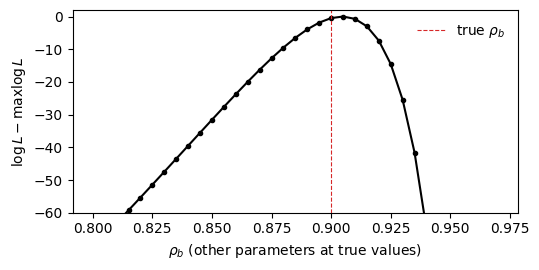

In [10]:
def ex59(th):
    beta, delta, gam, e, mub, mud, rhob, rhod, sigb, sigd = th
    A = np.array([[1 - delta, 0, 0, 0], [0, rhob, 0, mub * (1 - rhob)], [0, 0, rhod, mud * (1 - rhod)], [0, 0, 0, 1.0]])
    B = np.array([[1.0], [0], [0], [0]])
    C = np.array([[0, 0], [sigb, 0], [0, sigd], [0, 0.0]])
    S = np.array([[gam, -1, 1, 0.0]])
    R, Q, H = 0.5 * S.T @ S, np.array([[0.5 * (1 + e)]]), -0.5 * S
    P, F, _ = olrp(beta, A, B, R, Q, H)
    G = np.vstack([S[0] + F[0] + np.array([0, 1, 0, 0]), -F[0]])   # z = [c, i] = G x   (c = gam k + d - i)
    return dict(A=A, B=B, C=C, P=P, F=F, Ao=A - B @ F, G=G)

beta9, delta9 = 0.95, 0.1
th0 = np.array([beta9, delta9, 1 / beta9 - 1 + delta9, 1.0, 30.0, 5.0, 0.9, 0.8, 1.0, 1.0])
m9 = ex59(th0)
print("F =", m9["F"][0], "  eig(A-BF) =", np.round(np.linalg.eigvals(m9["Ao"]), 5))
# Part I(b): certainty equivalence -- F independent of sigma_b, sigma_d; only d changes
for sb, sd in ((3.0, 1.0), (1.0, 3.0)):
    th = th0.copy(); th[8], th[9] = sb, sd; mm = ex59(th)
    assert np.allclose(mm["F"], m9["F"]) and np.allclose(mm["P"], m9["P"])
    print(f"sigma_b={sb}, sigma_d={sd}: d = {d_const(beta9, mm['P'], mm['C']):.3f}  (baseline {d_const(beta9, m9['P'], m9['C']):.3f})")
assert np.allclose(m9["F"], dare(beta9, m9["A"], m9["B"], 0.5 * np.outer([th0[2], -1, 1, 0], [th0[2], -1, 1, 0]),
                                 np.array([[1.0]]), -0.5 * np.array([[th0[2], -1, 1, 0]]))[1], atol=1e-7)

# Part II(a): Kalman-filter log likelihood of z_0..z_T, vs direct Gaussian density of the stacked vector
def loglik(th, Z, mu0, Sig0):
    mm = ex59(th); Ao, C, G = mm["Ao"], mm["C"], mm["G"]
    xh, Sg, ll = mu0.copy(), Sig0.copy(), 0.0
    for z in Z:
        Om = G @ Sg @ G.T; a = z - G @ xh
        ll += -0.5 * (len(z) * np.log(2 * np.pi) + np.linalg.slogdet(Om)[1] + a @ np.linalg.solve(Om, a))
        K = Ao @ Sg @ G.T @ np.linalg.inv(Om)
        xh = Ao @ xh + K @ a
        Sg = Ao @ Sg @ Ao.T + C @ C.T - K @ Om @ K.T
    return ll

def simulate59(th, T, x0, seed):
    mm = ex59(th); rng = np.random.default_rng(seed); x = x0.copy(); Z = []
    for t in range(T + 1):
        Z.append(mm["G"] @ x); x = mm["Ao"] @ x + mm["C"] @ rng.standard_normal(2)
    return np.array(Z)

mu0 = np.array([10.0, 30.0, 5.0, 1.0]); Sig0 = np.diag([4.0, 1.0, 1.0, 0.0])
Zs = simulate59(th0, 12, mu0 + np.array([1.0, -0.5, 0.3, 0]), seed=9)
# direct route: stacked z = Gbig x0 + Ebig eps, Gaussian
Ao, C, G = m9["Ao"], m9["C"], m9["G"]; Tn = len(Zs)
mean = np.concatenate([G @ np.linalg.matrix_power(Ao, t) @ mu0 for t in range(Tn)])
L0 = np.vstack([G @ np.linalg.matrix_power(Ao, t) for t in range(Tn)])
Lsh = np.zeros((2 * Tn, 2 * Tn))
for t in range(Tn):
    for s in range(1, t + 1):
        Lsh[2 * t:2 * t + 2, 2 * (s - 1):2 * s] = G @ np.linalg.matrix_power(Ao, t - s) @ C
Cov = L0 @ Sig0 @ L0.T + Lsh @ Lsh.T
dev = Zs.ravel() - mean
ll_direct = -0.5 * (len(dev) * np.log(2 * np.pi) + np.linalg.slogdet(Cov)[1] + dev @ np.linalg.solve(Cov, dev))
ll_kf = loglik(th0, Zs, mu0, Sig0)
assert np.isclose(ll_kf, ll_direct, rtol=1e-8)
print(f"log L (Kalman) = {ll_kf:.6f}   log L (direct Gaussian) = {ll_direct:.6f}")
# profile likelihood in rho_b on a long sample: maximised near the truth
Zl = simulate59(th0, 600, mu0, seed=10)
grid = np.linspace(0.8, 0.97, 35); prof = []
for rb in grid:
    th = th0.copy(); th[6] = rb; prof.append(loglik(th, Zl, mu0, Sig0))
rb_hat = grid[int(np.argmax(prof))]
assert abs(rb_hat - 0.9) < 0.05
print("argmax of the rho_b profile:", rb_hat)
fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.plot(grid, np.array(prof) - max(prof), "k.-"); ax.axvline(0.9, color="C3", lw=0.8, ls="--", label=r"true $\rho_b$")
ax.set_xlabel(r"$\rho_b$ (other parameters at true values)"); ax.set_ylabel(r"$\log L-\max\log L$")
ax.set_ylim(-60, 2); ax.legend(frameon=False); fig.tight_layout(); fig.savefig(FIG + "ls05_likelihood.pdf"); plt.show()

## Exercise 5.10 --- value of a prescribed consumption rule, then Howard

$x_t=[k_t,y_t,y_{t-1},1]'$. Under $c_t=\alpha y_t+(R-1)k_t$ the closed loop is
$k_{t+1}=R(2-R)k_t+R(1-\alpha)y_t$, and $v(x)=-x'P_0x-d_0$ with $P_0=\tfrac12S'S+\beta A_0'P_0A_0$, $S=[R-1,\alpha,0,-b]$.
Howard with $u=c$ converges to the permanent-income rule $c_t=(1-\beta)\,[k_t+\sum_j\beta^jE_ty_{t+j}]$.
Parameters (not in the book): $\beta=.95$, $R=1/\beta$, $b=3$, $\alpha=.5$, $\mu_y=1$, $\rho_1=1.2$, $\rho_2=-.3$, $\sigma_y=.1$.

In [11]:
beta10, Rr, bb, al, muy, r1, r2, sy = 0.95, 1 / 0.95, 3.0, 0.5, 1.0, 1.2, -0.3, 0.1
A10 = np.array([[Rr, Rr, 0, 0], [0, r1, r2, muy * (1 - r1 - r2)], [0, 1, 0, 0], [0, 0, 0, 1.0]])
B10 = np.array([[-Rr], [0], [0], [0]])
C10 = np.array([[0], [sy], [0], [0.0]])
e4 = np.array([[0, 0, 0, 1.0]])
R10, Q10, H10 = 0.5 * bb**2 * e4.T @ e4, np.array([[0.5]]), -0.5 * bb * e4     # -(1/2)(c-b)^2 with u=c
F_pres = -np.array([[Rr - 1, al, 0, 0]])                                         # c = alpha y + (R-1)k = -F x
P0_10 = evaluate(beta10, A10, B10, R10, Q10, H10, F_pres)
d0_10 = d_const(beta10, P0_10, C10)
# independent route: the book-form Lyapunov with S directly, and Monte Carlo
S10 = np.array([[Rr - 1, al, 0, -bb]]); Acl = A10 - B10 @ F_pres
assert np.allclose(Acl[0], [Rr * (2 - Rr), Rr * (1 - al), 0, 0])
assert np.allclose(P0_10, solve_discrete_lyapunov(np.sqrt(beta10) * Acl.T, 0.5 * S10.T @ S10), rtol=1e-9)
x0 = np.array([2.0, 1.1, 1.0, 1.0]); rng = np.random.default_rng(10); N = 20_000
X = np.tile(x0, (N, 1)); tot = np.zeros(N)
for t in range(700):
    tot += -0.5 * beta10**t * (X @ S10[0])**2
    X = X @ Acl.T + np.outer(rng.standard_normal(N), C10[:, 0])
v_lq = -(x0 @ P0_10 @ x0) - d0_10; se = tot.std() / np.sqrt(N)
assert abs(tot.mean() - v_lq) < 5 * se
print(f"value of the prescribed rule at x0: {v_lq:.5f}; Monte Carlo {tot.mean():.5f} +/- {se:.5f}")
# Howard from the prescribed rule
P10, F10, it10, hist10 = howard(beta10, A10, B10, R10, Q10, H10, F_pres)
Ay = A10[1:, 1:]; gy = np.array([1.0, 0, 0]) @ np.linalg.inv(np.eye(3) - beta10 * Ay)
c_pih = (1 - beta10) * np.concatenate([[1.0], gy])                               # c = c_pih @ x
assert np.allclose(-F10[0], c_pih, atol=1e-8)
print(f"Howard: {it10} improvements. Limit rule c = {-F10[0]};  PIH closed form {c_pih}")
print("first improvement:", -hist10[1][0])
print("eig(A-BF) at the limit:", np.round(np.linalg.eigvals(A10 - B10 @ F10), 6))
# the Riccati iteration from P=0 instead converges to P=0, i.e. c=b forever (Ponzi): the no-Ponzi bound is
# what Howard's stable starting rule imposes
Pz, Fz, _ = olrp(beta10, A10, B10, R10, Q10, H10)
assert np.allclose(Pz, 0) and np.allclose(-Fz[0], [0, 0, 0, bb])

value of the prescribed rule at x0: -37.20880; Monte Carlo -37.22943 +/- 0.02878
Howard: 5 improvements. Limit rule c = [ 0.05     0.38241 -0.10899  0.72658];  PIH closed form [ 0.05     0.38241 -0.10899  0.72658]
first improvement: [ 0.05013  0.38723 -0.11043  0.69939]
eig(A-BF) at the limit: [1.      0.84495 0.35505 1.     ]


## Exercise 5.11 --- firm with adjustment costs (deterministic)

$x_t=[y_t,Y_t,1]'$, $u_t=y_{t+1}-y_t$. Return $p_ty_t-\tfrac d2u_t^2=-(x'Rx+u'Qu)$ with
$R=\begin{bmatrix}0&A_1/2&-A_0/2\\A_1/2&0&0\\-A_0/2&0&0\end{bmatrix}$, $Q=d/2$.
Euler closed form: $y_{t+1}-y_t=\frac1d\sum_{j\ge0}\beta^{j+1}p_{t+1+j}$.

In [12]:
def firm(beta, d, A0, A1, H0, H1, H2=0.0, rho=0.0, sig=0.0):
    """Exercises 5.11-5.12: x=[y, Y, u, 1], control Delta y. Returns P, F, A, B, C, R, Q."""
    A = np.array([[1, 0, 0, 0], [0, H1, H2, H0], [0, 0, rho, 0], [0, 0, 0, 1.0]])
    B = np.array([[1.0], [0], [0], [0]]); C = np.array([[0], [0], [sig], [0.0]])
    R = np.zeros((4, 4)); R[0, 1] = R[1, 0] = A1 / 2; R[0, 3] = R[3, 0] = -A0 / 2; R[0, 2] = R[2, 0] = -0.5
    Q = np.array([[d / 2]])
    P, F, it = olrp(beta, A, B, R, Q)
    return P, F, A, B, C, R, Q, it

pars11 = dict(beta=0.95, d=2.0, A0=100.0, A1=1.0, H0=200.0, H1=0.8)
P11, F11, A11, B11, C11, R11, Q11, it11 = firm(**pars11)
be, d_, A0, A1, H0, H1 = pars11.values()
Ybar = H0 / (1 - H1)
# closed form rule: Delta y = (1/d)[beta(A0-A1 Ybar)/(1-beta) - A1 beta H1 (Y-Ybar)/(1-beta H1)]
slope = -A1 * be * H1 / (d_ * (1 - be * H1)); const = (be * (A0 - A1 * Ybar) / (1 - be) + A1 * be * H1 * Ybar / (1 - be * H1)) / d_
assert np.allclose(-F11[0], [0, slope, 0, const], atol=1e-7)
# value: linear coefficient on y equals sum_s beta^s p_{t+s}
assert np.isclose(-2 * P11[0, 1], -A1 / (1 - be * H1))
assert np.isclose(-2 * P11[0, 3], A0 / (1 - be) - A1 * Ybar * (1 / (1 - be) - 1 / (1 - be * H1)))
assert abs(P11[0, 0]) < 1e-9
# value by direct simulation from (y0, Y0)
y, Y, tot = 10.0, 50.0, 0.0; xv = np.array([10.0, 50.0, 0, 1.0])
for t in range(3000):
    dy = -F11[0] @ np.array([y, Y, 0, 1.0]); tot += be**t * ((A0 - A1 * Y) * y - 0.5 * d_ * dy**2)
    y, Y = y + dy, H0 + H1 * Y
assert np.isclose(tot, -xv @ P11 @ xv, rtol=1e-9)
print(f"Riccati iterations: {it11}.  Rule: y' - y = {const:.4f} + ({slope:.6f}) Y")
print("P (x=[y,Y,1]):\n", P11[np.ix_([0, 1, 3], [0, 1, 3])])
print("value at (y,Y)=(10,50):", -xv @ P11 @ xv)

Riccati iterations: 562.  Rule: y' - y = -6966.6667 + (-1.583333) Y
P (x=[y,Y,1]):
 [[ 0.00000e+00  2.08333e+00  6.91667e+03]
 [ 2.08333e+00 -6.39527e+00 -5.00110e+04]
 [ 6.91667e+03 -5.00110e+04 -1.35563e+09]]
value at (y,Y)=(10,50): 1360509436.2692502


## Exercise 5.12 --- adding an AR(1) demand shock

$x_t=[y_t,Y_t,u_t,1]'$. By certainty equivalence $y_{t+1}-y_t=\frac1d\,g'\beta A_z(I-\beta A_z)^{-1}z_t$ with
$z=[Y,u,1]'$, $g=[-A_1,1,A_0]'$, $A_z=\begin{bmatrix}H_1&H_2&H_0\\0&\rho&0\\0&0&1\end{bmatrix}$.

In [13]:
pars12 = dict(beta=0.95, d=2.0, A0=100.0, A1=1.0, H0=200.0, H1=0.8, H2=2.0, rho=0.9, sig=0.05)
P12, F12, A12, B12, C12, R12, Q12, it12 = firm(**pars12)
Az = np.array([[0.8, 2.0, 200.0], [0, 0.9, 0], [0, 0, 1.0]]); gv = np.array([-1.0, 1.0, 100.0])
rule = gv @ (0.95 * Az) @ np.linalg.inv(np.eye(3) - 0.95 * Az) / 2.0
assert np.allclose(-F12[0], np.concatenate([[0.0], rule]), atol=1e-7)
lin = gv @ np.linalg.inv(np.eye(3) - 0.95 * Az)               # coefficient on y in v: sum_s beta^s E p_{t+s}
assert np.allclose(-2 * P12[0, 1:], lin, atol=1e-7)
d12 = d_const(0.95, P12, C12)
# the deterministic part coincides with 5.11 (certainty equivalence: sigma_u only moves d)
assert np.allclose(F12[0, [0, 1, 3]], F11[0, [0, 1, 3]])
assert np.allclose(firm(**{**pars12, "sig": 0.5})[1], F12)
# Monte Carlo value check at x0
x0 = np.array([10.0, 50.0, 0.2, 1.0]); rng = np.random.default_rng(12); N = 20_000
X = np.tile(x0, (N, 1)); tot = np.zeros(N)
for t in range(800):
    U = -X @ F12[0]
    tot += 0.95**t * ((100 - X[:, 1] + X[:, 2]) * X[:, 0] - U**2)
    X = X @ A12.T + np.outer(U, B12[:, 0]) + np.outer(rng.standard_normal(N), C12[:, 0])
v12 = -(x0 @ P12 @ x0) - d12; se = tot.std() / np.sqrt(N)
assert abs(tot.mean() - v12) < 5 * se
print("rule: y'-y = [0, Y, u, 1] coeffs", -F12[0], "\nd =", d12, " value at x0:", v12, " MC:", tot.mean(), "+/-", se)
print("P:\n", P12)

rule: y'-y = [0, Y, u, 1] coeffs [   -0.         -1.58333   -24.35057 -6966.66667] 
d = -234.868846114837  value at x0: 1361321704.4896727  MC: 1361311662.5066988 +/- 9712.742296276774
P:
 [[ 0.00000e+00  2.08333e+00  2.38506e+01  6.91667e+03]
 [ 2.08333e+00 -6.39527e+00 -1.52772e+02 -5.00110e+04]
 [ 2.38506e+01 -1.52772e+02 -4.94461e+03 -2.02219e+06]
 [ 6.91667e+03 -5.00110e+04 -2.02219e+06 -1.35563e+09]]


## Exercises 5.13 and 5.14 --- permanent income with a tiny penalty on assets

$x_t=[a_t,\,y\text{-lags},\,1]'$, $u_t=c_t$, $a_{t+1}=Ra_t+y_t-c_t$. Return
$-\tfrac12(c-b)^2-\tfrac12\epsilon a^2$: $R=\tfrac12\epsilon e_1e_1'+\tfrac12b^2e_ne_n'$, $Q=\tfrac12$, $H=-\tfrac12b\,e_n'$.
Hall benchmark (stabilising solution with $\epsilon=0$): $c_t=(1-\beta)[Ra_t+\sum_j\beta^jE_ty_{t+j}]$.

===== Exercise 5.13 =====
eps=1e-6: Riccati iterations 772; c = -F x with -F = [ 0.05265  0.22631 -0.086    0.85968] 
  d = 0.0243
  eig(A-BF): [0.99998+0.j  0.6    +0.2j 0.6    -0.2j 1.     +0.j ]  |.|: [0.99998 0.63246 0.63246 1.     ]
  P =
 [[      0.02771       0.11911      -0.04526    -525.86332]
 [      0.11911       0.51202      -0.19456   -2260.49845]
 [     -0.04526      -0.19456       0.07393     858.98941]
 [   -525.86332   -2260.49845     858.98941 9982812.82126]]
eps=0, stabilising solution = Hall rule: [ 0.05263  0.22624 -0.08597  0.85973] 
  eig(A-BF): [1. +0.j  0.6+0.2j 0.6-0.2j 1. +0.j ]
  max |F(eps=1e-6) - F_Hall| = 6.983884891240133e-05
===== Exercise 5.14 =====
eps=1e-6: Riccati iterations 772; c = -F x with -F = [0.05265 0.2145  0.05517 0.05808 0.06113 0.61112] 
  d = 0.0218
  eig(A-BF): [ 0.99998+0.j       0.92682+0.j       0.12807+0.70354j  0.12807-0.70354j -0.63297+0.j       1.     +0.j     ]  |.|: [0.99998 0.92682 0.71511 0.71511 0.63297 1.     ]
  P =
 [[   

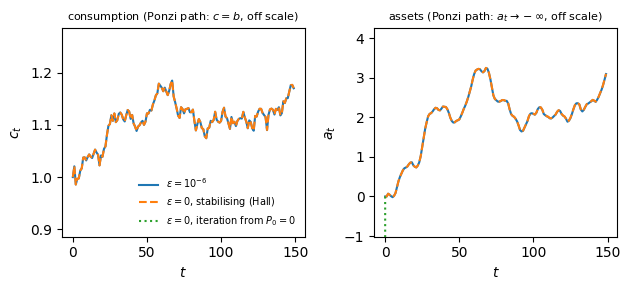

In [14]:
def pih(lags, rho1, rho2, eps, beta=0.95, b=1000.0, sig=0.05):
    """x = [a, y_t, ..., y_{t-lags+1}, 1]. y_{t+1} = (1-rho1-rho2) + rho1 y_t + rho2 y_{t-lags+1} + sig eps."""
    n = lags + 2; Rr = 1 / beta
    A = np.zeros((n, n)); A[0, 0] = Rr; A[0, 1] = 1
    A[1, 1] += rho1; A[1, lags] += rho2; A[1, -1] = 1 - rho1 - rho2
    for j in range(2, lags + 1):
        A[j, j - 1] = 1
    A[-1, -1] = 1
    B = np.zeros((n, 1)); B[0] = -1; C = np.zeros((n, 1)); C[1] = sig
    R = np.zeros((n, n)); R[0, 0] = 0.5 * eps; R[-1, -1] = 0.5 * b**2
    Q = np.array([[0.5]]); H = np.zeros((1, n)); H[0, -1] = -0.5 * b
    return A, B, C, R, Q, H

def hall_rule(A, beta):
    Ay = A[1:, 1:]; gy = np.eye(len(Ay))[0] @ np.linalg.inv(np.eye(len(Ay)) - beta * Ay)
    return (1 - beta) * np.concatenate([[1 / beta], gy])          # c = rule @ x

out = {}
for ex, lags, r1_, r2_ in (("5.13", 2, 1.2, -0.4), ("5.14", 4, 0.55, 0.3)):
    print(f"===== Exercise {ex} =====")
    A, B, C, R, Q, H = pih(lags, r1_, r2_, 1e-6)
    Pe, Fe, ite = olrp(0.95, A, B, R, Q, H, tol=1e-15, maxit=2_000_000)
    Pd_, Fd_ = dare(0.95, A, B, R, Q, H)
    assert np.allclose(Fe, Fd_, atol=1e-6)
    de = d_const(0.95, Pe, C)
    eig = np.linalg.eigvals(A - B @ Fe)
    print(f"eps=1e-6: Riccati iterations {ite}; c = -F x with -F =", -Fe[0], f"\n  d = {de:.4f}")
    print("  eig(A-BF):", np.round(eig, 6), " |.|:", np.round(np.abs(eig), 6))
    print("  P =\n", Pe)
    # eps = 0: iteration from P=0 stays at P=0 (c=b, Ponzi); the stabilising solution is Hall's rule
    A0_, B0_, C0_, R0_, Q0_, H0_ = pih(lags, r1_, r2_, 0.0)
    Pz, Fz, _ = olrp(0.95, A0_, B0_, R0_, Q0_, H0_)
    assert np.allclose(Pz, 0) and np.allclose(-Fz[0], np.r_[np.zeros(lags + 1), 1000.0])
    assert np.max(abs(np.linalg.eigvals(A0_ - B0_ @ Fz))) > 1 / np.sqrt(0.95)          # a explodes at rate R
    Ps, Fs = dare(0.95, A0_, B0_, R0_, Q0_, H0_)
    hall = hall_rule(A0_, 0.95)
    assert np.allclose(-Fs[0], hall, atol=1e-8)
    assert np.allclose(-Fe[0], hall, atol=1e-3)                                     # eps -> 0 selects Hall
    eig0 = np.linalg.eigvals(A0_ - B0_ @ Fs)
    print("eps=0, stabilising solution = Hall rule:", -Fs[0], "\n  eig(A-BF):", np.round(eig0, 6))
    print("  max |F(eps=1e-6) - F_Hall| =", np.max(abs(Fe[0] + hall)))
    out[ex] = (A, B, C, Fe, A0_, B0_, Fz, Fs)

fig, axs = plt.subplots(1, 2, figsize=(6.5, 3.0))
rng = np.random.default_rng(13); shocks = rng.standard_normal(150)
A, B, C, Fe, A0_, B0_, Fz, Fs = out["5.13"]
for F_, lab, st in ((Fe, r"$\epsilon=10^{-6}$", "-"), (Fs, r"$\epsilon=0$, stabilising (Hall)", "--"),
                    (Fz, r"$\epsilon=0$, iteration from $P_0=0$", ":")):
    x = np.array([0.0, 1.0, 1.0, 1.0]); cs, as_ = [], []
    for t in range(150):
        c = -F_[0] @ x; cs.append(c); as_.append(x[0]); x = A0_ @ x + B0_[:, 0] * c + C[:, 0] * shocks[t]
    axs[0].plot(cs, st, label=lab); axs[1].plot(as_, st)
    if F_ is Fs:
        lim_c, lim_a = (min(cs) - 0.1, max(cs) + 0.1), (min(as_) - 1, max(as_) + 1)
axs[0].set_ylim(*lim_c); axs[0].set_xlabel("$t$"); axs[0].set_ylabel("$c_t$"); axs[0].legend(frameon=False, fontsize=7)
axs[1].set_ylim(*lim_a); axs[1].set_xlabel("$t$"); axs[1].set_ylabel("$a_t$")
axs[0].set_title("consumption (Ponzi path: $c=b$, off scale)", fontsize=8); axs[1].set_title(r"assets (Ponzi path: $a_t\to-\infty$, off scale)", fontsize=8)
fig.tight_layout(); fig.savefig(FIG + "ls05_pih.pdf"); plt.show()

In [15]:
print("All assertions passed.")

All assertions passed.
